# Tugas 1 - Klasifikasi Wine Quality dengan KNN

| Nama              | NRP        |
|-------------------|------------|
| Rayyan Muhtar Ali | 5054251051 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.

# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
data = pd.read_csv('WineQT.csv')

print('jumlah baris dan kolom :', data.shape)
data.head()

jumlah baris dan kolom : (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [5]:
# cek missing value sama duplikat dulu sebelum lanjut
print(data.isna().sum())
print()
print('total missing value :', data.isna().sum().sum())

# kolom Id gak diikutin waktu ngecek duplikat karena isinya unik semua
print('jumlah baris duplikat :', data.drop(columns=['Id']).duplicated().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

total missing value : 0
jumlah baris duplikat : 125


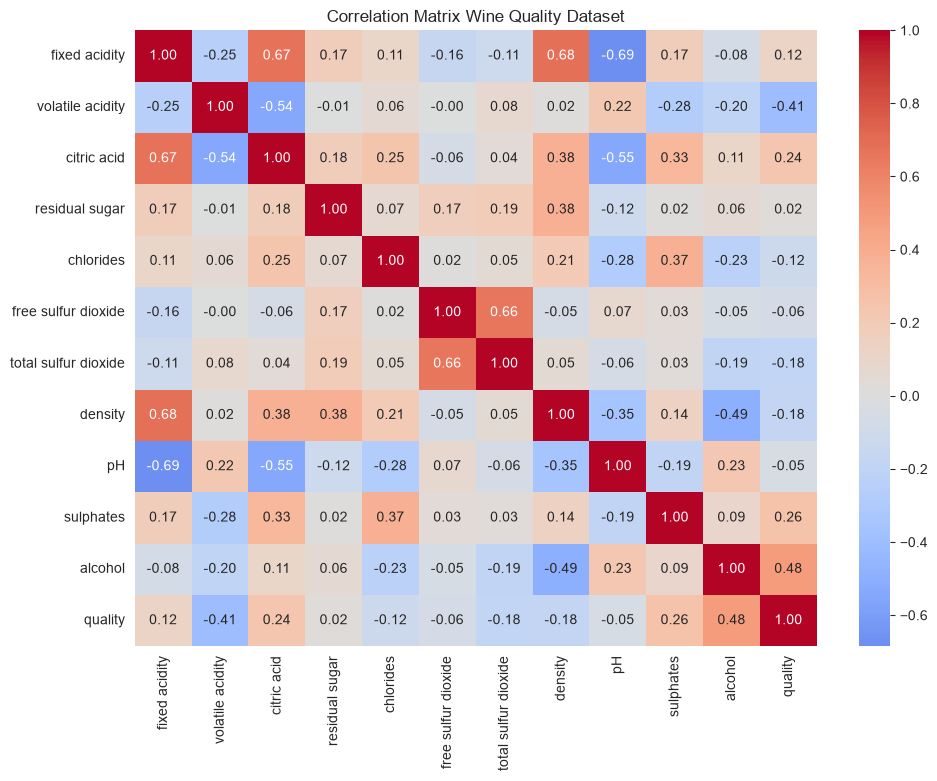

In [6]:
# Tampilkan Korelasi Matrix

korelasi = data.drop(columns=['Id']).corr()

plt.figure(figsize=(11, 8))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix Wine Quality Dataset')
plt.show()

In [7]:
# korelasi tiap fitur ke label quality, diurutkan dari yang paling kuat
korelasi['quality'].drop('quality').sort_values(key=abs, ascending=False)

alcohol                 0.484866
volatile acidity       -0.407394
sulphates               0.257710
citric acid             0.240821
total sulfur dioxide   -0.183339
density                -0.175208
chlorides              -0.124085
fixed acidity           0.121970
free sulfur dioxide    -0.063260
pH                     -0.052453
residual sugar          0.022002
Name: quality, dtype: float64

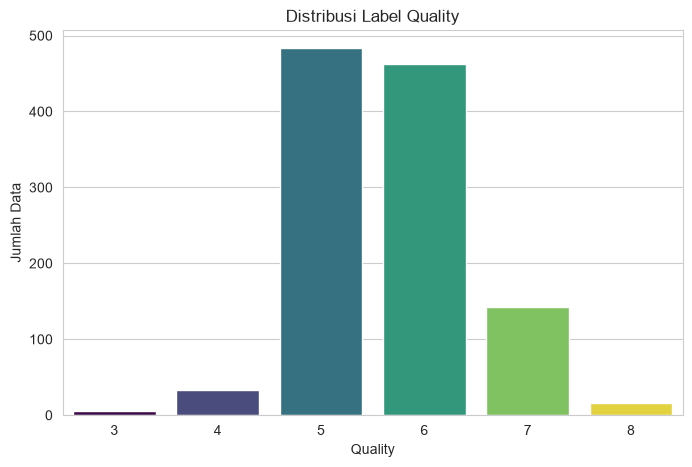

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

proporsi tiap kelas (%) :
quality
3     0.52
4     2.89
5    42.26
6    40.42
7    12.51
8     1.40
Name: proportion, dtype: float64


In [8]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.

sns.countplot(x='quality', data=data, hue='quality', palette='viridis', legend=False)
plt.title('Distribusi Label Quality')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')
plt.show()

print(data['quality'].value_counts().sort_index())
print()
print('proporsi tiap kelas (%) :')
print((data['quality'].value_counts(normalize=True).sort_index() * 100).round(2))

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

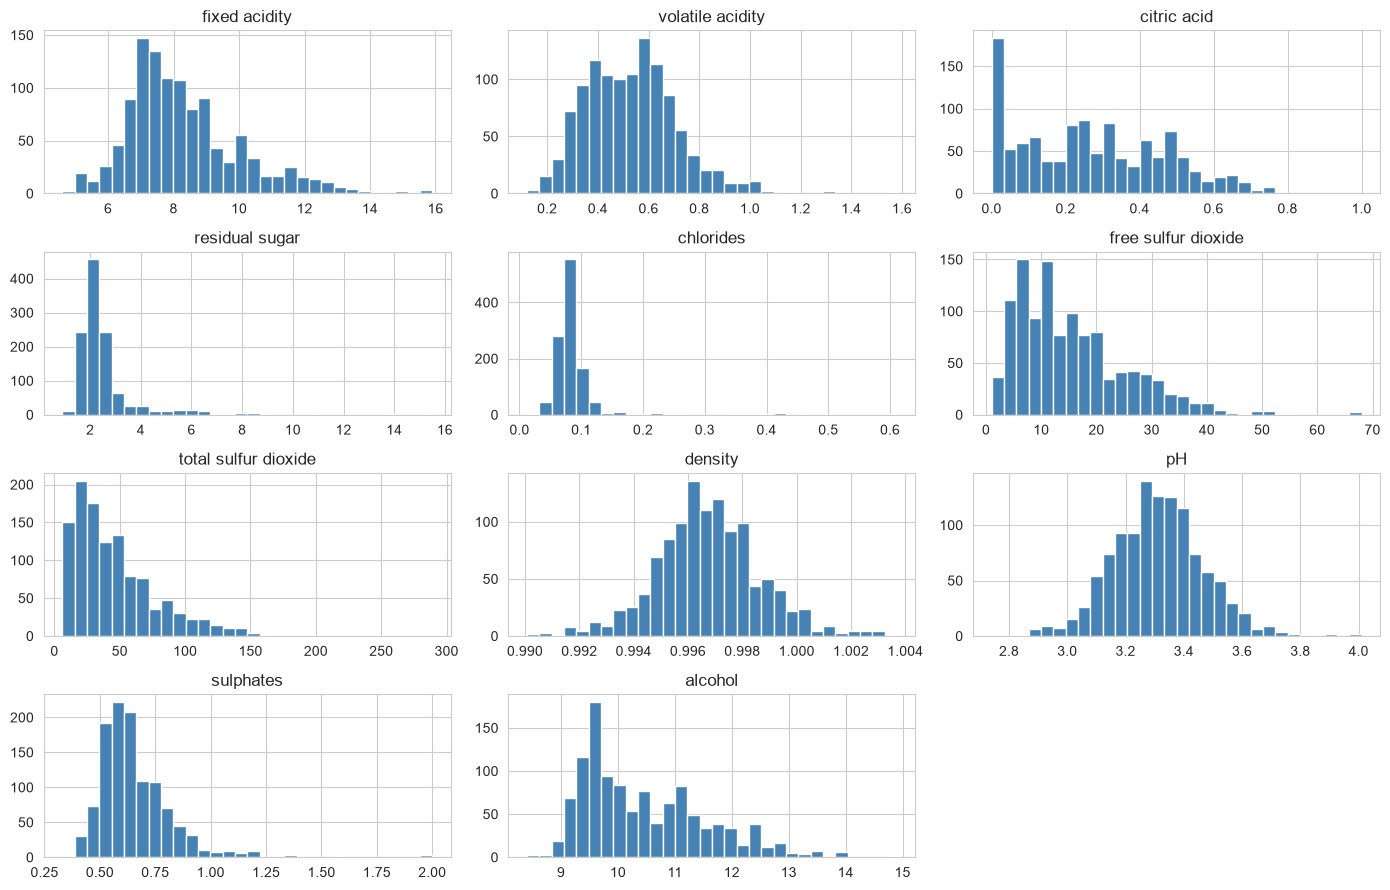

In [9]:
# sebaran tiap fitur, buat lihat mana yang distribusinya miring
data.drop(columns=['Id', 'quality']).hist(bins=30, figsize=(14, 9), color='steelblue')
plt.tight_layout()
plt.show()

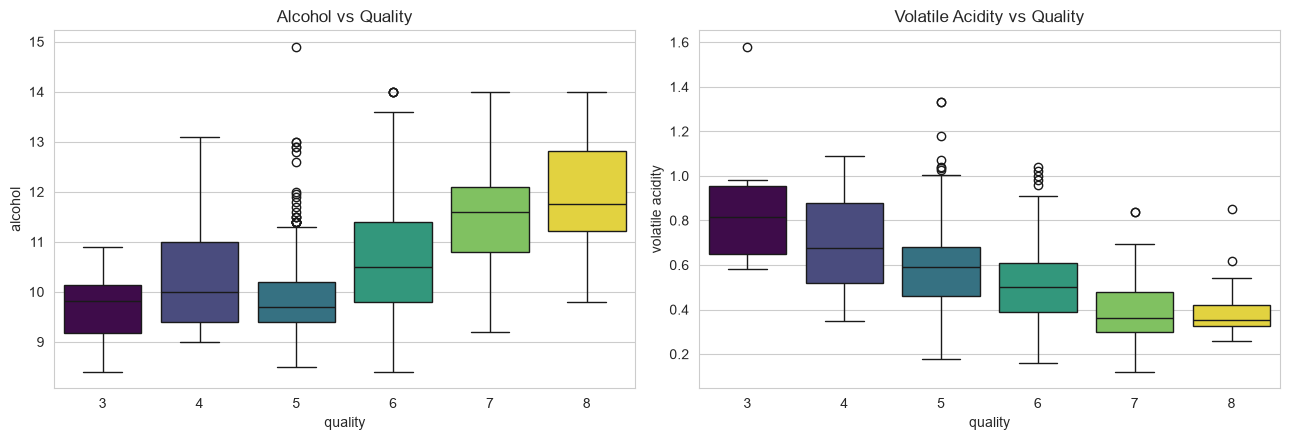

In [10]:
# dari correlation matrix tadi, alcohol sama volatile acidity yang paling nyambung ke quality,
# jadi saya lihat sebarannya per kelas
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(x='quality', y='alcohol', data=data, hue='quality', palette='viridis', legend=False, ax=ax[0])
ax[0].set_title('Alcohol vs Quality')

sns.boxplot(x='quality', y='volatile acidity', data=data, hue='quality', palette='viridis', legend=False, ax=ax[1])
ax[1].set_title('Volatile Acidity vs Quality')

plt.tight_layout()
plt.show()

In [11]:
# rata-rata beberapa fitur yang korelasinya lumayan, dikelompokkan per quality
data.groupby('quality')[['alcohol', 'volatile acidity', 'sulphates', 'citric acid']].mean().round(3)

,alcohol,volatile acidity,sulphates,citric acid
quality,,,,
3,9.692,0.898,0.550,0.212
4,10.261,0.700,0.638,0.166
5,9.902,0.585,0.613,0.240
6,10.655,0.505,0.677,0.264
7,11.483,0.394,0.744,0.387
8,11.938,0.410,0.766,0.432


Dari EDA di atas:

- Datanya 1143 baris, 11 fitur numerik, label `quality`, dan kolom `Id` yang cuma nomor urut.
- Gak ada missing value, tapi ada 125 baris duplikat.
- Labelnya timpang banget. Quality 5 dan 6 saja sudah 82% data, sedangkan quality 3 cuma 6 baris dan quality 8 cuma 16 baris.
- Fitur yang paling nyambung ke quality itu `alcohol` (0.48) dan `volatile acidity` (-0.41).
- Skala antar fitur beda jauh, `total sulfur dioxide` sampai ratusan sedangkan `density` cuma di 0.99-an. Buat KNN ini ngaruh karena jaraknya bakal didominasi fitur yang angkanya besar.

# 2. Preprocessing

In [12]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.

# tidak ada NaN jadi gak perlu imputasi.
# kolom Id dibuang karena cuma penomoran, kalau ikut dipakai malah jadi fitur palsu buat KNN.
df = data.drop(columns=['Id'])

print('sebelum drop duplikat :', df.shape)
df = df.drop_duplicates().reset_index(drop=True)
print('sesudah drop duplikat :', df.shape)
print()
print(df['quality'].value_counts().sort_index())

sebelum drop duplikat : (1143, 12)
sesudah drop duplikat : (1018, 12)

quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64


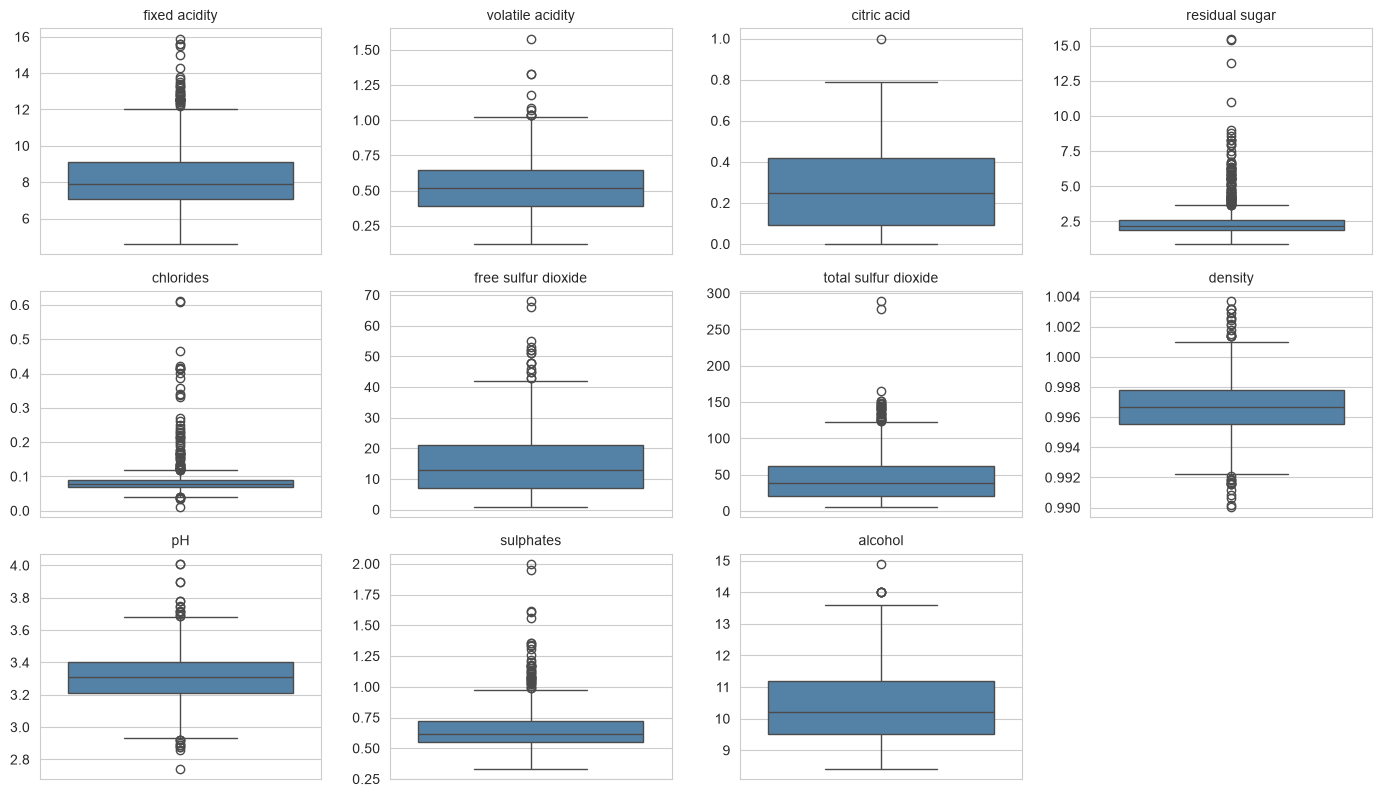

In [13]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)

fitur = df.drop(columns=['quality'])

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
axes = axes.flatten()
for i, kolom in enumerate(fitur.columns):
    sns.boxplot(y=fitur[kolom], ax=axes[i], color='steelblue')
    axes[i].set_title(kolom, fontsize=10)
    axes[i].set_ylabel('')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [14]:
# hitung jumlah outlier tiap fitur pakai IQR
Q1 = fitur.quantile(0.25)
Q3 = fitur.quantile(0.75)
IQR = Q3 - Q1

is_outlier = (fitur < Q1 - 1.5 * IQR) | (fitur > Q3 + 1.5 * IQR)
print(is_outlier.sum().sort_values(ascending=False))
print()

tanpa_outlier = ~is_outlier.any(axis=1)
print('baris yang bersih dari outlier :', tanpa_outlier.sum(), 'dari', len(fitur))
print()
print('distribusi quality kalau semua outlier dibuang :')
print(df.loc[tanpa_outlier, 'quality'].value_counts().sort_index())

residual sugar          95
chlorides               71
sulphates               41
fixed acidity           37
total sulfur dioxide    33
density                 30
pH                      24
free sulfur dioxide     16
volatile acidity        10
alcohol                  6
citric acid              1
dtype: int64

baris yang bersih dari outlier : 756 dari 1018

distribusi quality kalau semua outlier dibuang :
quality
3      3
4     20
5    326
6    316
7     81
8     10
Name: count, dtype: int64


In [15]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

X = df.drop(columns=['quality'])
y = df['quality']

print('X :', X.shape)
print('y :', y.shape)

# scaling-nya sengaja belum dilakukan di sini. StandardScaler baru di-fit setelah data displit
# di bagian 3, karena kalau di-fit ke seluruh data, mean dan std punya data test ikut kepakai
# dan itu sudah termasuk data leakage.

X : (1018, 11)
y : (1018,)


# 3. Eksperimen Model KNN

In [16]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('data train :', X_train.shape)
print('data test  :', X_test.shape)
print()
print('proporsi label train (%) :')
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))
print()
print('proporsi label test (%) :')
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

data train : (814, 11)
data test  : (204, 11)

proporsi label train (%) :
quality
3     0.61
4     3.19
5    42.51
6    40.17
7    12.04
8     1.47
Name: proportion, dtype: float64

proporsi label test (%) :
quality
3     0.49
4     3.43
5    42.65
6    40.20
7    11.76
8     1.47
Name: proportion, dtype: float64


In [17]:
# scaler di-fit cuma pakai data train, data test tinggal di-transform
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# di data train mean-nya harus mendekati 0 dan std mendekati 1
print('mean train :', X_train_scaled.mean().round(4), '| std train :', X_train_scaled.std().round(4))
print('mean test  :', X_test_scaled.mean().round(4), '| std test  :', X_test_scaled.std().round(4))

mean train : 0.0 | std train : 1.0
mean test  : -0.005 | std test  : 1.0225


In [18]:
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

list_k = list(range(1, 26, 2))    # k ganjil 1 sampai 25 biar votingnya gak gampang seri
list_metric = ['euclidean', 'manhattan']

hasil = []
for metric in list_metric:
    for k in list_k:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train_scaled, y_train)

        pred_train = knn.predict(X_train_scaled)
        pred_test = knn.predict(X_test_scaled)

        hasil.append({
            'metric': metric,
            'k': k,
            'akurasi_train': accuracy_score(y_train, pred_train),
            'akurasi_test': accuracy_score(y_test, pred_test),
            'precision': precision_score(y_test, pred_test, average='weighted', zero_division=0),
            'recall': recall_score(y_test, pred_test, average='weighted', zero_division=0),
            'f1': f1_score(y_test, pred_test, average='weighted', zero_division=0),
        })

hasil = pd.DataFrame(hasil).round(4)
hasil

,metric,k,akurasi_train,akurasi_test,precision,recall,f1
0,euclidean,1,1.0000,0.5147,0.5257,0.5147,0.5187
1,euclidean,3,0.7346,0.5098,0.5169,0.5098,0.5122
2,euclidean,5,0.6781,0.5588,0.5416,0.5588,0.5498
3,euclidean,7,0.6548,0.5686,0.5516,0.5686,0.5593
4,euclidean,9,0.6474,0.5784,0.5544,0.5784,0.5627
5,euclidean,11,0.6462,0.5784,0.5540,0.5784,0.5624
6,euclidean,13,0.6216,0.5833,0.5584,0.5833,0.5640
7,euclidean,15,0.6339,0.5882,0.5527,0.5882,0.5670
8,euclidean,17,0.6204,0.5882,0.5503,0.5882,0.5653
9,euclidean,19,0.6044,0.5980,0.5660,0.5980,0.5773


In [19]:
# 5 kombinasi dengan akurasi test paling tinggi
hasil.sort_values('akurasi_test', ascending=False).head(5)

,metric,k,akurasi_train,akurasi_test,precision,recall,f1
9,euclidean,19,0.6044,0.5980,0.5660,0.5980,0.5773
7,euclidean,15,0.6339,0.5882,0.5527,0.5882,0.5670
8,euclidean,17,0.6204,0.5882,0.5503,0.5882,0.5653
6,euclidean,13,0.6216,0.5833,0.5584,0.5833,0.5640
4,euclidean,9,0.6474,0.5784,0.5544,0.5784,0.5627


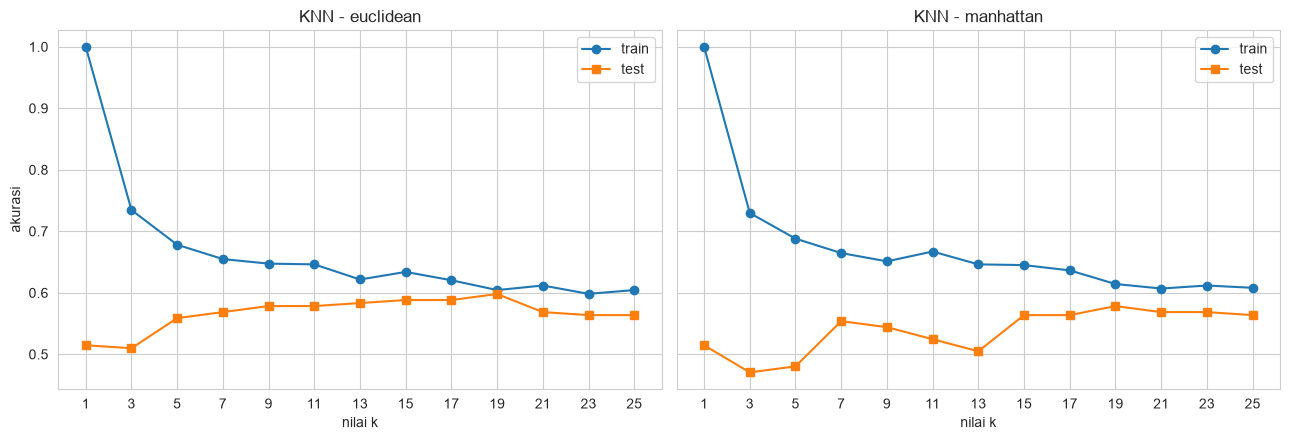

In [20]:
# bandingin akurasi train vs test buat tiap nilai k
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for i, metric in enumerate(list_metric):
    subset = hasil[hasil['metric'] == metric]
    ax[i].plot(subset['k'], subset['akurasi_train'], marker='o', label='train')
    ax[i].plot(subset['k'], subset['akurasi_test'], marker='s', label='test')
    ax[i].set_title('KNN - ' + metric)
    ax[i].set_xlabel('nilai k')
    ax[i].set_xticks(list_k)
    ax[i].legend()

ax[0].set_ylabel('akurasi')
plt.tight_layout()
plt.show()

In [21]:
# eksperimen tambahan: gimana kalau datanya gak di-scaling, dan gimana kalau outliernya dibuang.
# biar adil, cara split dan daftar k-nya sama persis, yang beda cuma perlakuan datanya.

def eksperimen(X_, y_, pakai_scaling=True):
    X_tr, X_te, y_tr, y_te = train_test_split(X_, y_, test_size=0.2, random_state=42, stratify=y_)
    if pakai_scaling:
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

    baris = []
    for metric in list_metric:
        for k in list_k:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
            knn.fit(X_tr, y_tr)
            pred = knn.predict(X_te)
            baris.append({
                'metric': metric,
                'k': k,
                'akurasi_test': accuracy_score(y_te, pred),
                'f1': f1_score(y_te, pred, average='weighted', zero_division=0),
            })
    return pd.DataFrame(baris)

hasil_tanpa_scaling = eksperimen(X, y, pakai_scaling=False)
hasil_tanpa_outlier = eksperimen(X[tanpa_outlier], y[tanpa_outlier], pakai_scaling=True)

perbandingan = pd.DataFrame([
    {'skenario': 'scaling (dipakai di atas)', 'jumlah_data': len(X),
     'akurasi_terbaik': hasil['akurasi_test'].max(), 'rata2_akurasi': hasil['akurasi_test'].mean()},
    {'skenario': 'tanpa scaling', 'jumlah_data': len(X),
     'akurasi_terbaik': hasil_tanpa_scaling['akurasi_test'].max(), 'rata2_akurasi': hasil_tanpa_scaling['akurasi_test'].mean()},
    {'skenario': 'scaling + outlier dibuang', 'jumlah_data': int(tanpa_outlier.sum()),
     'akurasi_terbaik': hasil_tanpa_outlier['akurasi_test'].max(), 'rata2_akurasi': hasil_tanpa_outlier['akurasi_test'].mean()},
]).round(4)

perbandingan

,skenario,jumlah_data,akurasi_terbaik,rata2_akurasi
0,scaling (dipakai di atas),1018,0.5980,0.5524
1,tanpa scaling,1018,0.5588,0.5041
2,scaling + outlier dibuang,756,0.6316,0.5741


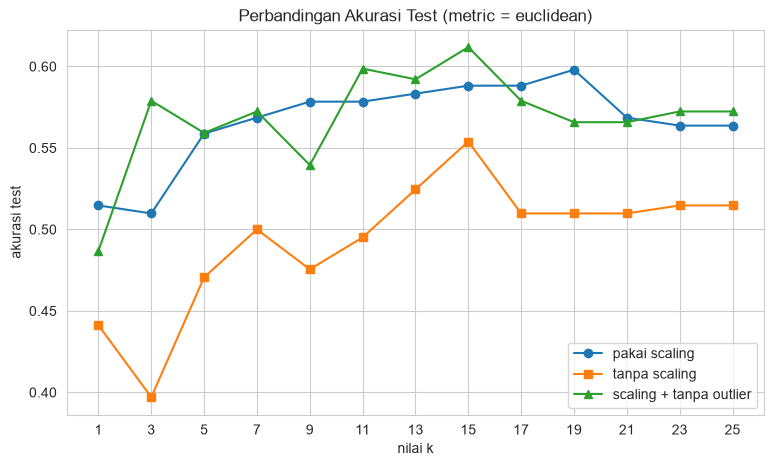

In [22]:
# biar kelihatan selisihnya, saya plot yang metric euclidean saja
plt.figure(figsize=(9, 5))
plt.plot(list_k, hasil[hasil['metric'] == 'euclidean']['akurasi_test'], marker='o', label='pakai scaling')
plt.plot(list_k, hasil_tanpa_scaling[hasil_tanpa_scaling['metric'] == 'euclidean']['akurasi_test'], marker='s', label='tanpa scaling')
plt.plot(list_k, hasil_tanpa_outlier[hasil_tanpa_outlier['metric'] == 'euclidean']['akurasi_test'], marker='^', label='scaling + tanpa outlier')
plt.title('Perbandingan Akurasi Test (metric = euclidean)')
plt.xlabel('nilai k')
plt.ylabel('akurasi test')
plt.xticks(list_k)
plt.legend()
plt.show()

# 4. Evaluasi Model

In [23]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

# ambil kombinasi terbaik dari tabel eksperimen bagian 3
terbaik = hasil.sort_values('akurasi_test', ascending=False).iloc[0]
k_terbaik = int(terbaik['k'])
metric_terbaik = terbaik['metric']
print('model terbaik -> k =', k_terbaik, ', metric =', metric_terbaik)

model = KNeighborsClassifier(n_neighbors=k_terbaik, metric=metric_terbaik)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print()
print('Accuracy  :', round(accuracy_score(y_test, y_pred), 4))
print('Precision :', round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4))
print('Recall    :', round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4))
print('F1-Score  :', round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4))
print()
# macro average dilihat juga buat tahu performanya kalau semua kelas dianggap sama penting
print('F1-Score (macro) :', round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4))

model terbaik -> k = 19 , metric = euclidean

Accuracy  : 0.598
Precision : 0.566
Recall    : 0.598
F1-Score  : 0.5773

F1-Score (macro) : 0.2808


In [24]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.67      0.70      0.69        87
           6       0.54      0.65      0.59        82
           7       0.53      0.33      0.41        24
           8       0.00      0.00      0.00         3

    accuracy                           0.60       204
   macro avg       0.29      0.28      0.28       204
weighted avg       0.57      0.60      0.58       204



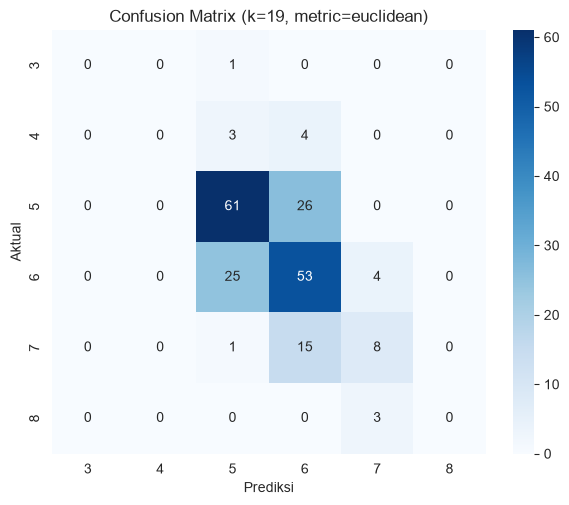

In [25]:
cm = confusion_matrix(y_test, y_pred)
label = sorted(y_test.unique())

plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label, yticklabels=label)
plt.title('Confusion Matrix (k=' + str(k_terbaik) + ', metric=' + metric_terbaik + ')')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

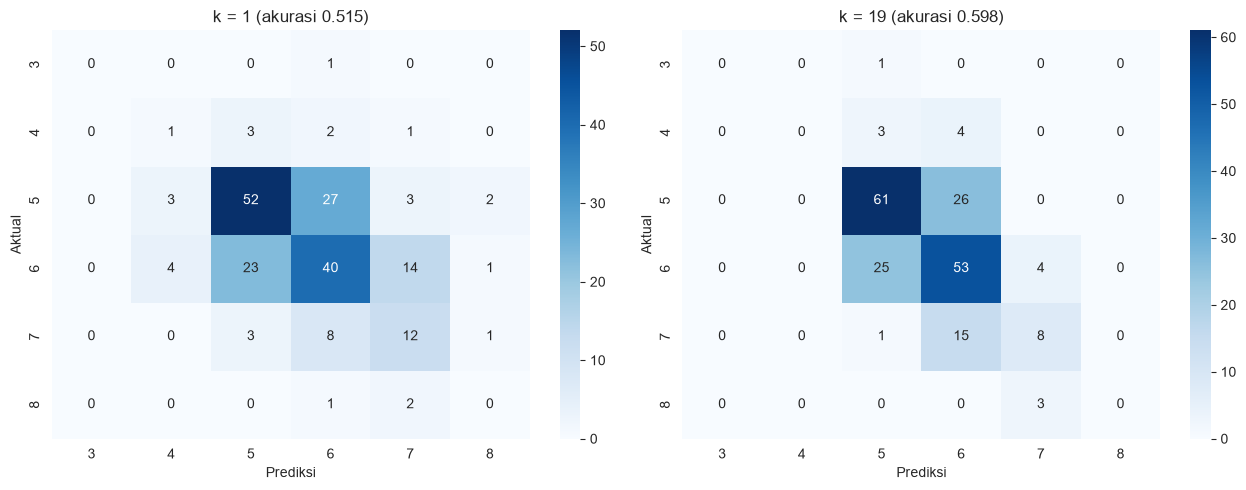

In [26]:
# dibandingkan sama k=1 yang tadi overfit, biar kelihatan bedanya di confusion matrix
knn1 = KNeighborsClassifier(n_neighbors=1, metric=metric_terbaik)
knn1.fit(X_train_scaled, y_train)
pred1 = knn1.predict(X_test_scaled)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(confusion_matrix(y_test, pred1), annot=True, fmt='d', cmap='Blues',
            xticklabels=label, yticklabels=label, ax=ax[0])
ax[0].set_title('k = 1 (akurasi %.3f)' % accuracy_score(y_test, pred1))
ax[0].set_xlabel('Prediksi')
ax[0].set_ylabel('Aktual')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label, yticklabels=label, ax=ax[1])
ax[1].set_title('k = %d (akurasi %.3f)' % (k_terbaik, accuracy_score(y_test, y_pred)))
ax[1].set_xlabel('Prediksi')
ax[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

Dari eksperimen yang saya lakukan, nilai k paling ngaruh waktu angkanya kecil. Di k = 1 akurasi train-nya 100% tapi di test cuma 51.47%, jadi jelas overfitting, soalnya tetangga terdekat dari sebuah data train ya dirinya sendiri. Pas k dinaikin akurasi train malah turun tapi akurasi test naik, paling tinggi di k = 19 dengan 59.80%, terus turun lagi jadi 56.86% di k = 21.

Untuk metric jaraknya, euclidean sedikit lebih bagus dari manhattan (59.80% lawan 57.84%). Selisihnya kecil, tapi euclidean lebih stabil, sedangkan manhattan sempat jatuh di k = 3 dan k = 5 sampai sekitar 47-48% baru naik lagi.

Yang selisihnya paling kelihatan justru scaling. Rata-rata akurasi pakai scaling 0.5524, tanpa scaling cuma 0.5041. Masuk akal karena KNN kerjanya murni ngitung jarak, kalau gak di-scaling fitur seperti `total sulfur dioxide` yang rentangnya 6 sampai 289 bakal mendominasi, sementara `density` yang cuma main di 0.99 sampai 1.00 nyaris gak ngefek.

Eksperimen buang outlier hasilnya kelihatan lebih tinggi (63.16%), tapi menurut saya gak bisa langsung dibandingin karena datanya berkurang 26% (1018 jadi 756), jadi test set-nya juga jadi beda dan isinya cuma data yang rapi. Kelas minoritasnya juga makin dikit, quality 3 tinggal 3 baris. Makanya model utama saya tetap pakai data lengkap.

Model terbaiknya (k = 19, euclidean) dapat accuracy 0.5980 dan F1 weighted 0.5773, tapi F1 macro-nya cuma 0.2808. Bedanya jauh karena quality 3, 4, dan 8 sama sekali gak pernah keprediksi, precision dan recall-nya 0 semua. Di data train jumlahnya memang cuma 5, 26, dan 12 baris, jadi susah menang voting lawan quality 5 dan 6 yang ratusan. Dari confusion matrix, salahnya juga kebanyakan nyerempet ke kelas sebelahnya, misalnya 26 dari 87 wine quality 5 diprediksi jadi 6 dan 15 dari 24 quality 7 ketarik ke 6.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulannya, model KNN terbaik yang saya dapat adalah k = 19 dengan metric euclidean dan data yang sudah distandarisasi, akurasi test 59.80% dan F1 weighted 0.5773. Nilai k kecil bikin overfitting dan scaling jadi preprocessing yang paling menentukan di tugas ini karena KNN sensitif ke perbedaan skala fitur. Masalah terbesarnya bukan di akurasi, tapi di ketimpangan kelas: quality 3, 4, dan 8 gak pernah keprediksi, makanya F1 macro-nya cuma 0.2808. Jadi buat data yang timpang begini, lihat accuracy doang bisa menyesatkan.

Sarannya, pemilihan k sebaiknya jangan dari akurasi data test kayak yang saya lakukan, lebih baik pakai cross validation biar data test cuma dipakai sekali di akhir. Ketimpangan kelasnya juga perlu ditangani, misalnya pakai oversampling (SMOTE), `weights='distance'`, atau labelnya digabung jadi rendah, sedang, dan tinggi. Terakhir, hasil ini sebaiknya dibandingkan dengan algoritma lain seperti Decision Tree buat tahu akurasi 60% ini batas datanya atau memang kelemahan KNN.